In [14]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

from src.data_manager import generate_crisis_data
from src.causal_engine import UpliftCausalEngine
from src.mcda_engine import run_committee_mcda
from src.validator import validate_shock_input

Data Generator Validation

In [16]:
df = generate_crisis_data(2.0)

df.head()

,Global_Oil_Risk,DOE_Optimization,UPLIFT_Intensity,Stability_Index
0,114.901425,73.993554,0.443590,51.827649
1,95.852071,69.246337,0.408682,70.007368
2,119.430656,60.596304,0.452845,51.887461
3,145.690896,53.530632,0.630954,44.718752
4,92.975399,66.982233,0.207871,73.693884


In [9]:
df.describe()

,Global_Oil_Risk,DOE_Optimization,UPLIFT_Intensity,Stability_Index
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,100.579962,60.708362,0.447497,68.842372
std,29.376478,9.974544,0.177985,21.093510
min,2.761980,30.596114,0.000000,-1.960699
25%,80.572291,53.937583,0.319656,55.325380
50%,100.759018,60.630771,0.445649,68.771305
75%,119.438316,67.288822,0.574708,83.034518
max,215.581945,91.931076,1.000000,135.594468


In [18]:
df.corr(numeric_only=True)

,Global_Oil_Risk,DOE_Optimization,UPLIFT_Intensity,Stability_Index
Global_Oil_Risk,1.000000,-0.040400,0.807026,-0.952878
DOE_Optimization,-0.040400,1.000000,-0.038691,0.165394
UPLIFT_Intensity,0.807026,-0.038691,1.000000,-0.693155
Stability_Index,-0.952878,0.165394,-0.693155,1.000000


In [19]:
engine = UpliftCausalEngine(df)

ate = engine.estimate_causal_lift()

print("ATE:", ate)

DEBUG: Graph: 
        digraph {
            Global_Oil_Risk -> UPLIFT_Intensity;
            Global_Oil_Risk -> Stability_Index;
            DOE_Optimization -> Stability_Index;
            UPLIFT_Intensity -> Stability_Index;
        }
        
DEBUG: Data Columns: ['Global_Oil_Risk', 'DOE_Optimization', 'UPLIFT_Intensity', 'Stability_Index']
2026-05-12 22:41:56,780 - src.causal_engine - INFO - Identifying Causal Effect using Explicit EO 110 DAG.
ATE: 25.82326859466351


/Users/david/Documents/2026/Causal_PhUplift/.venv/lib/python3.11/site-packages/dowhy/causal_estimator.py:236: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  # Grouping by effect modifiers and computing effect separately
/Users/david/Documents/2026/Causal_PhUplift/.venv/lib/python3.11/site-packages/dowhy/causal_estimators/regression_estimator.py:179: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  float, copy=False
/Users/david/Documents/2026/Causal_PhUplift/.venv/lib/python3.11/site-packages/dowhy/causal_estimators/regression_estimator.py:179: FutureWarning: Series.__getitem__ treating keys as positions is deprecate

In [20]:
levels = [0.0, 0.25, 0.5, 0.75, 0.95]

results = []

for lvl in levels:
    pred = engine.do_calculus_simulation(lvl)
    results.append((lvl, pred))

results

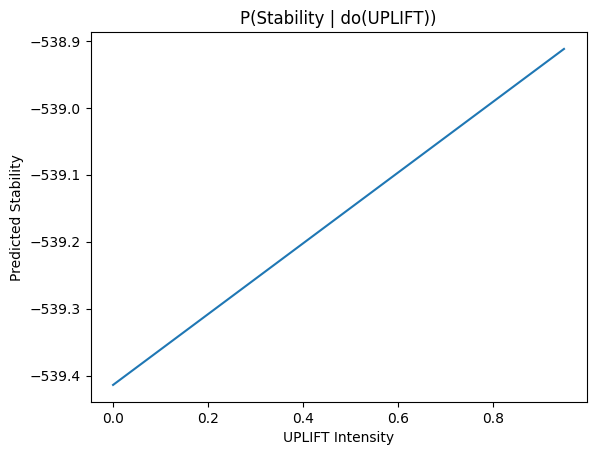

In [21]:
import matplotlib.pyplot as plt

x = [r[0] for r in results]
y = [r[1] for r in results]

plt.plot(x, y)
plt.title("P(Stability | do(UPLIFT))")
plt.xlabel("UPLIFT Intensity")
plt.ylabel("Predicted Stability")
plt.show()

In [22]:
scenarios = []

for lvl, pred in results:
    scenarios.append({
        "scenario": f"{lvl}",
        "intensity": lvl,
        "stability_pred": pred
    })

ranked, weights = run_committee_mcda(scenarios, 2.5)

ranked

,scenario,intensity,stability_pred,M_Stability,M_Welfare,M_Fiscal,n_M_Stability,n_M_Welfare,n_M_Fiscal,MCDA_Score
4,0.95,0.95,-538.911968,-538.911968,95.0,5.0,0.999998,1.000000,0.000000,0.899999
3,0.75,0.75,-539.017643,-539.017643,75.0,25.0,0.789472,0.789474,0.210526,0.731578
2,0.5,0.50,-539.149737,-539.149737,50.0,50.0,0.526315,0.526316,0.473684,0.521052
1,0.25,0.25,-539.281831,-539.281831,25.0,75.0,0.263157,0.263158,0.736842,0.310526
0,0.0,0.00,-539.413925,-539.413925,0.0,100.0,0.000000,0.000000,1.000000,0.100000


In [23]:
for shock in [1.0, 2.0, 3.0, 4.0]:
    df = generate_crisis_data(shock)

    engine = UpliftCausalEngine(df)

    ate = engine.estimate_causal_lift()

    print(f"Shock {shock} → ATE {ate:.2f}")

DEBUG: Graph: 
        digraph {
            Global_Oil_Risk -> UPLIFT_Intensity;
            Global_Oil_Risk -> Stability_Index;
            DOE_Optimization -> Stability_Index;
            UPLIFT_Intensity -> Stability_Index;
        }
        
DEBUG: Data Columns: ['Global_Oil_Risk', 'DOE_Optimization', 'UPLIFT_Intensity', 'Stability_Index']
2026-05-12 22:43:17,063 - src.causal_engine - INFO - Identifying Causal Effect using Explicit EO 110 DAG.
Shock 1.0 → ATE 25.77
DEBUG: Graph: 
        digraph {
            Global_Oil_Risk -> UPLIFT_Intensity;
            Global_Oil_Risk -> Stability_Index;
            DOE_Optimization -> Stability_Index;
            UPLIFT_Intensity -> Stability_Index;
        }
        
DEBUG: Data Columns: ['Global_Oil_Risk', 'DOE_Optimization', 'UPLIFT_Intensity', 'Stability_Index']
2026-05-12 22:43:17,118 - src.causal_engine - INFO - Identifying Causal Effect using Explicit EO 110 DAG.
Shock 2.0 → ATE 25.82
DEBUG: Graph: 
        digraph {
            Globa

/Users/david/Documents/2026/Causal_PhUplift/.venv/lib/python3.11/site-packages/dowhy/causal_estimator.py:236: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  # Grouping by effect modifiers and computing effect separately
/Users/david/Documents/2026/Causal_PhUplift/.venv/lib/python3.11/site-packages/dowhy/causal_estimators/regression_estimator.py:179: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  float, copy=False
/Users/david/Documents/2026/Causal_PhUplift/.venv/lib/python3.11/site-packages/dowhy/causal_estimators/regression_estimator.py:179: FutureWarning: Series.__getitem__ treating keys as positions is deprecate

In [24]:
print("=== VALIDATION SUMMARY ===")
print("ATE:", ate)
print("Monotonicity:", all(y[i] <= y[i+1] for i in range(len(y)-1)))
print("MCDA OK:", ranked is not None)

=== VALIDATION SUMMARY ===
ATE: 26.526768712566934
Monotonicity: True
MCDA OK: True
